In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Tasks: Calculate minimum, maximum, mean, median, standard deviation, and skewness for each feature
# Create histograms, boxplots, outlier table using IQR method, correlation heatmap & rankings

#Export CSV
filepath = "wdbc_clean.csv"
df = pd.read_csv(filepath, header= 0)

# Constants
ID_COL = "id"
TARGET_COL = "diagnosis"
ROWS = len(df)
FEATURES = 30
NUM_CALC = 6

# Headers
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET_COL]]
calculations = ["minimum", "maximum", "mean", "median", "standard deviation", "skewness"]

# Setting up Complete, Malignant, and Benign Arrays
features_df = df.iloc[:,2:]
M_df = []
B_df = []
for idx, result in enumerate(df[TARGET_COL]):
    if result == "M":
        M_df.append(features_df.iloc[idx,:])
    else:
        B_df.append(features_df.iloc[idx,:])
features_df = df.iloc[:,2:]
analysis_arr = np.zeros((FEATURES, NUM_CALC))

# Calculations
# Minimum
analysis_arr[:, 0] = features_df.min(axis = 0, numeric_only = True)
# Maximum
analysis_arr[:, 1] = features_df.max(axis = 0, numeric_only = True)
# Mean
analysis_arr[:, 2] = features_df.mean(axis = 0, numeric_only = True)
# Median
analysis_arr[:, 3] = features_df.median(axis = 0, numeric_only = True)
# Standard Deviation
analysis_arr[:, 4] = features_df.std(axis = 0, numeric_only = True)
# Skewness
analysis_arr[:, 5] = features_df.skew(axis = 0, numeric_only = True)

# Complete, Malignant, and Benign Data Frames
analysis_df = pd.DataFrame(analysis_arr, index = feature_cols, columns = calculations)
M_df = pd.DataFrame(M_df)
B_df = pd.DataFrame(B_df)

print("Feature Analysis Data: ")
print(analysis_df)

print(M_df.shape, B_df.shape)

Feature Analysis Data: 
                            minimum     maximum        mean      median  \
radius_mean                6.981000    28.11000   14.127292   13.370000   
texture_mean               9.710000    39.28000   19.289649   18.840000   
perimeter_mean            43.790000   188.50000   91.969033   86.240000   
area_mean                143.500000  2501.00000  654.889104  551.100000   
smoothness_mean            0.052630     0.16340    0.096360    0.095870   
compactness_mean           0.019380     0.34540    0.104341    0.092630   
concavity_mean             0.000000     0.42680    0.088799    0.061540   
concave_points_mean        0.000000     0.20120    0.048919    0.033500   
symmetry_mean              0.106000     0.30400    0.181162    0.179200   
fractal_dimension_mean     0.049960     0.09744    0.062798    0.061540   
radius_se                  0.111500     2.87300    0.405172    0.324200   
texture_se                 0.360200     4.88500    1.216853    1.108000   
p

In [8]:
def iqr_outlier_summary(df):
    summary = []
    for col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        summary.append({
            'feature': col,
            'n_outliers': n_outliers,
            'pct_outliers': round(100 * n_outliers / len(df), 2),
            'lower_bound': lower,
            'upper_bound': upper
        })
    return pd.DataFrame(summary).sort_values('pct_outliers', ascending=False)

outlier_summary = iqr_outlier_summary(features_df)
print("IQR Outlier Summary: ")
print(outlier_summary)

IQR Outlier Summary: 
                    feature  n_outliers  pct_outliers  lower_bound  \
13                  area_se          65         11.42   -23.160000   
10                radius_se          38          6.68    -0.137350   
12             perimeter_se          38          6.68    -1.020500   
23               area_worst          35          6.15  -337.750000   
14            smoothness_se          30          5.27     0.000703   
19     fractal_dimension_se          28          4.92    -0.001217   
15           compactness_se          28          4.92    -0.015975   
18              symmetry_se          27          4.75     0.002680   
3                 area_mean          25          4.39  -123.300000   
29  fractal_dimension_worst          24          4.22     0.040530   
28           symmetry_worst          23          4.04     0.149150   
16             concavity_se          22          3.87    -0.025350   
11               texture_se          20          3.51    -0.126250  

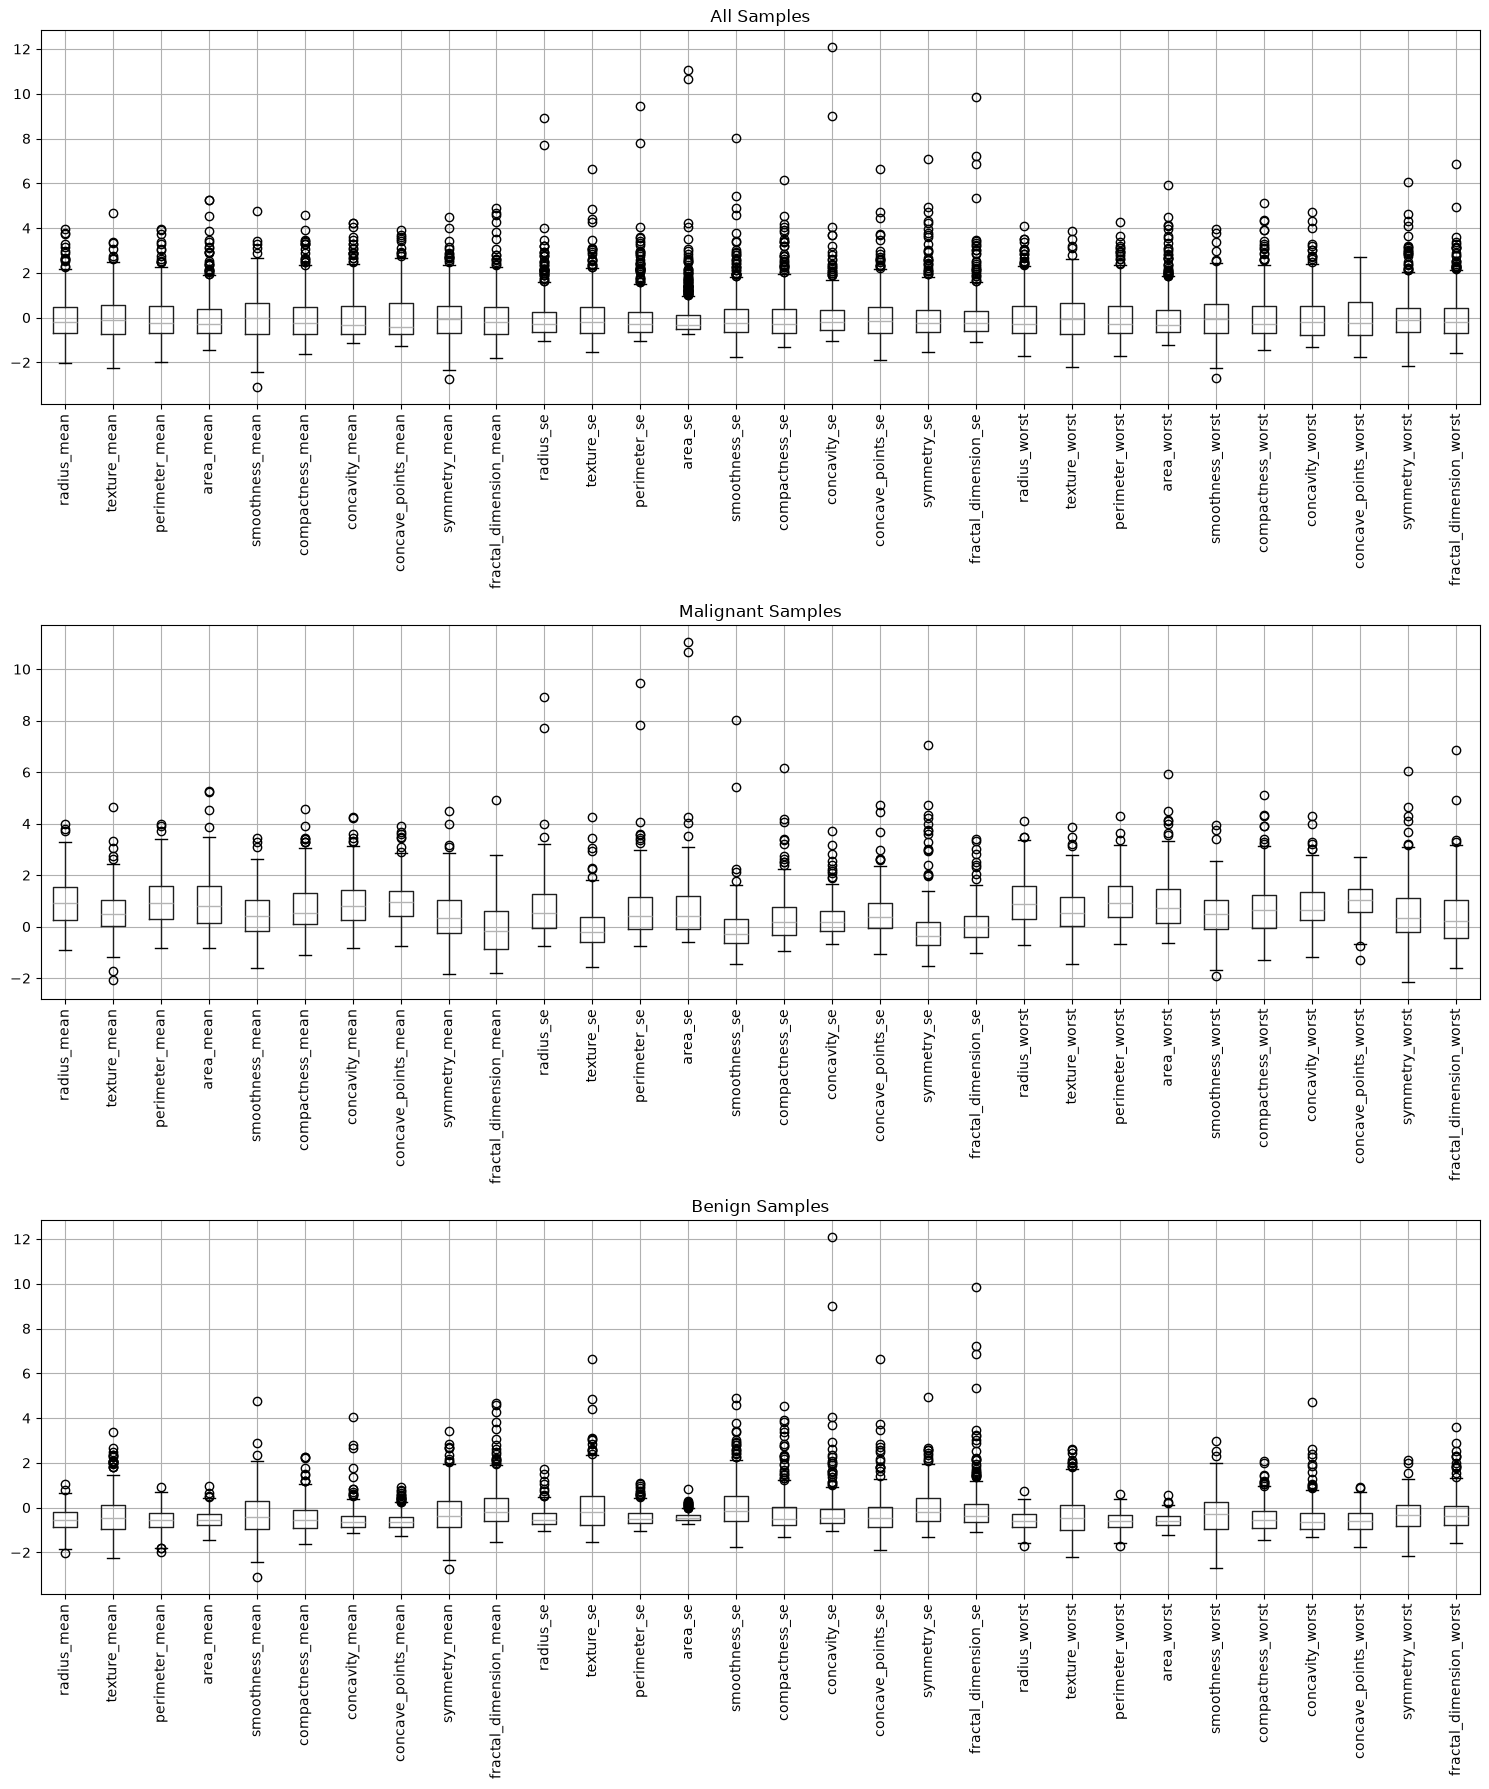

In [9]:
scaler = StandardScaler().fit(features_df)
scaled = pd.DataFrame(scaler.transform(features_df), columns=features_df.columns)
scaled_M = pd.DataFrame(scaler.transform(M_df), columns=features_df.columns)
scaled_B = pd.DataFrame(scaler.transform(B_df), columns=features_df.columns)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 18))

scaled.boxplot(rot=90, ax=axes[0])
axes[0].set_title("All Samples")

scaled_M.boxplot(rot=90, ax=axes[1])
axes[1].set_title("Malignant Samples")

scaled_B.boxplot(rot=90, ax=axes[2])
axes[2].set_title("Benign Samples")

plt.tight_layout()
plt.show()

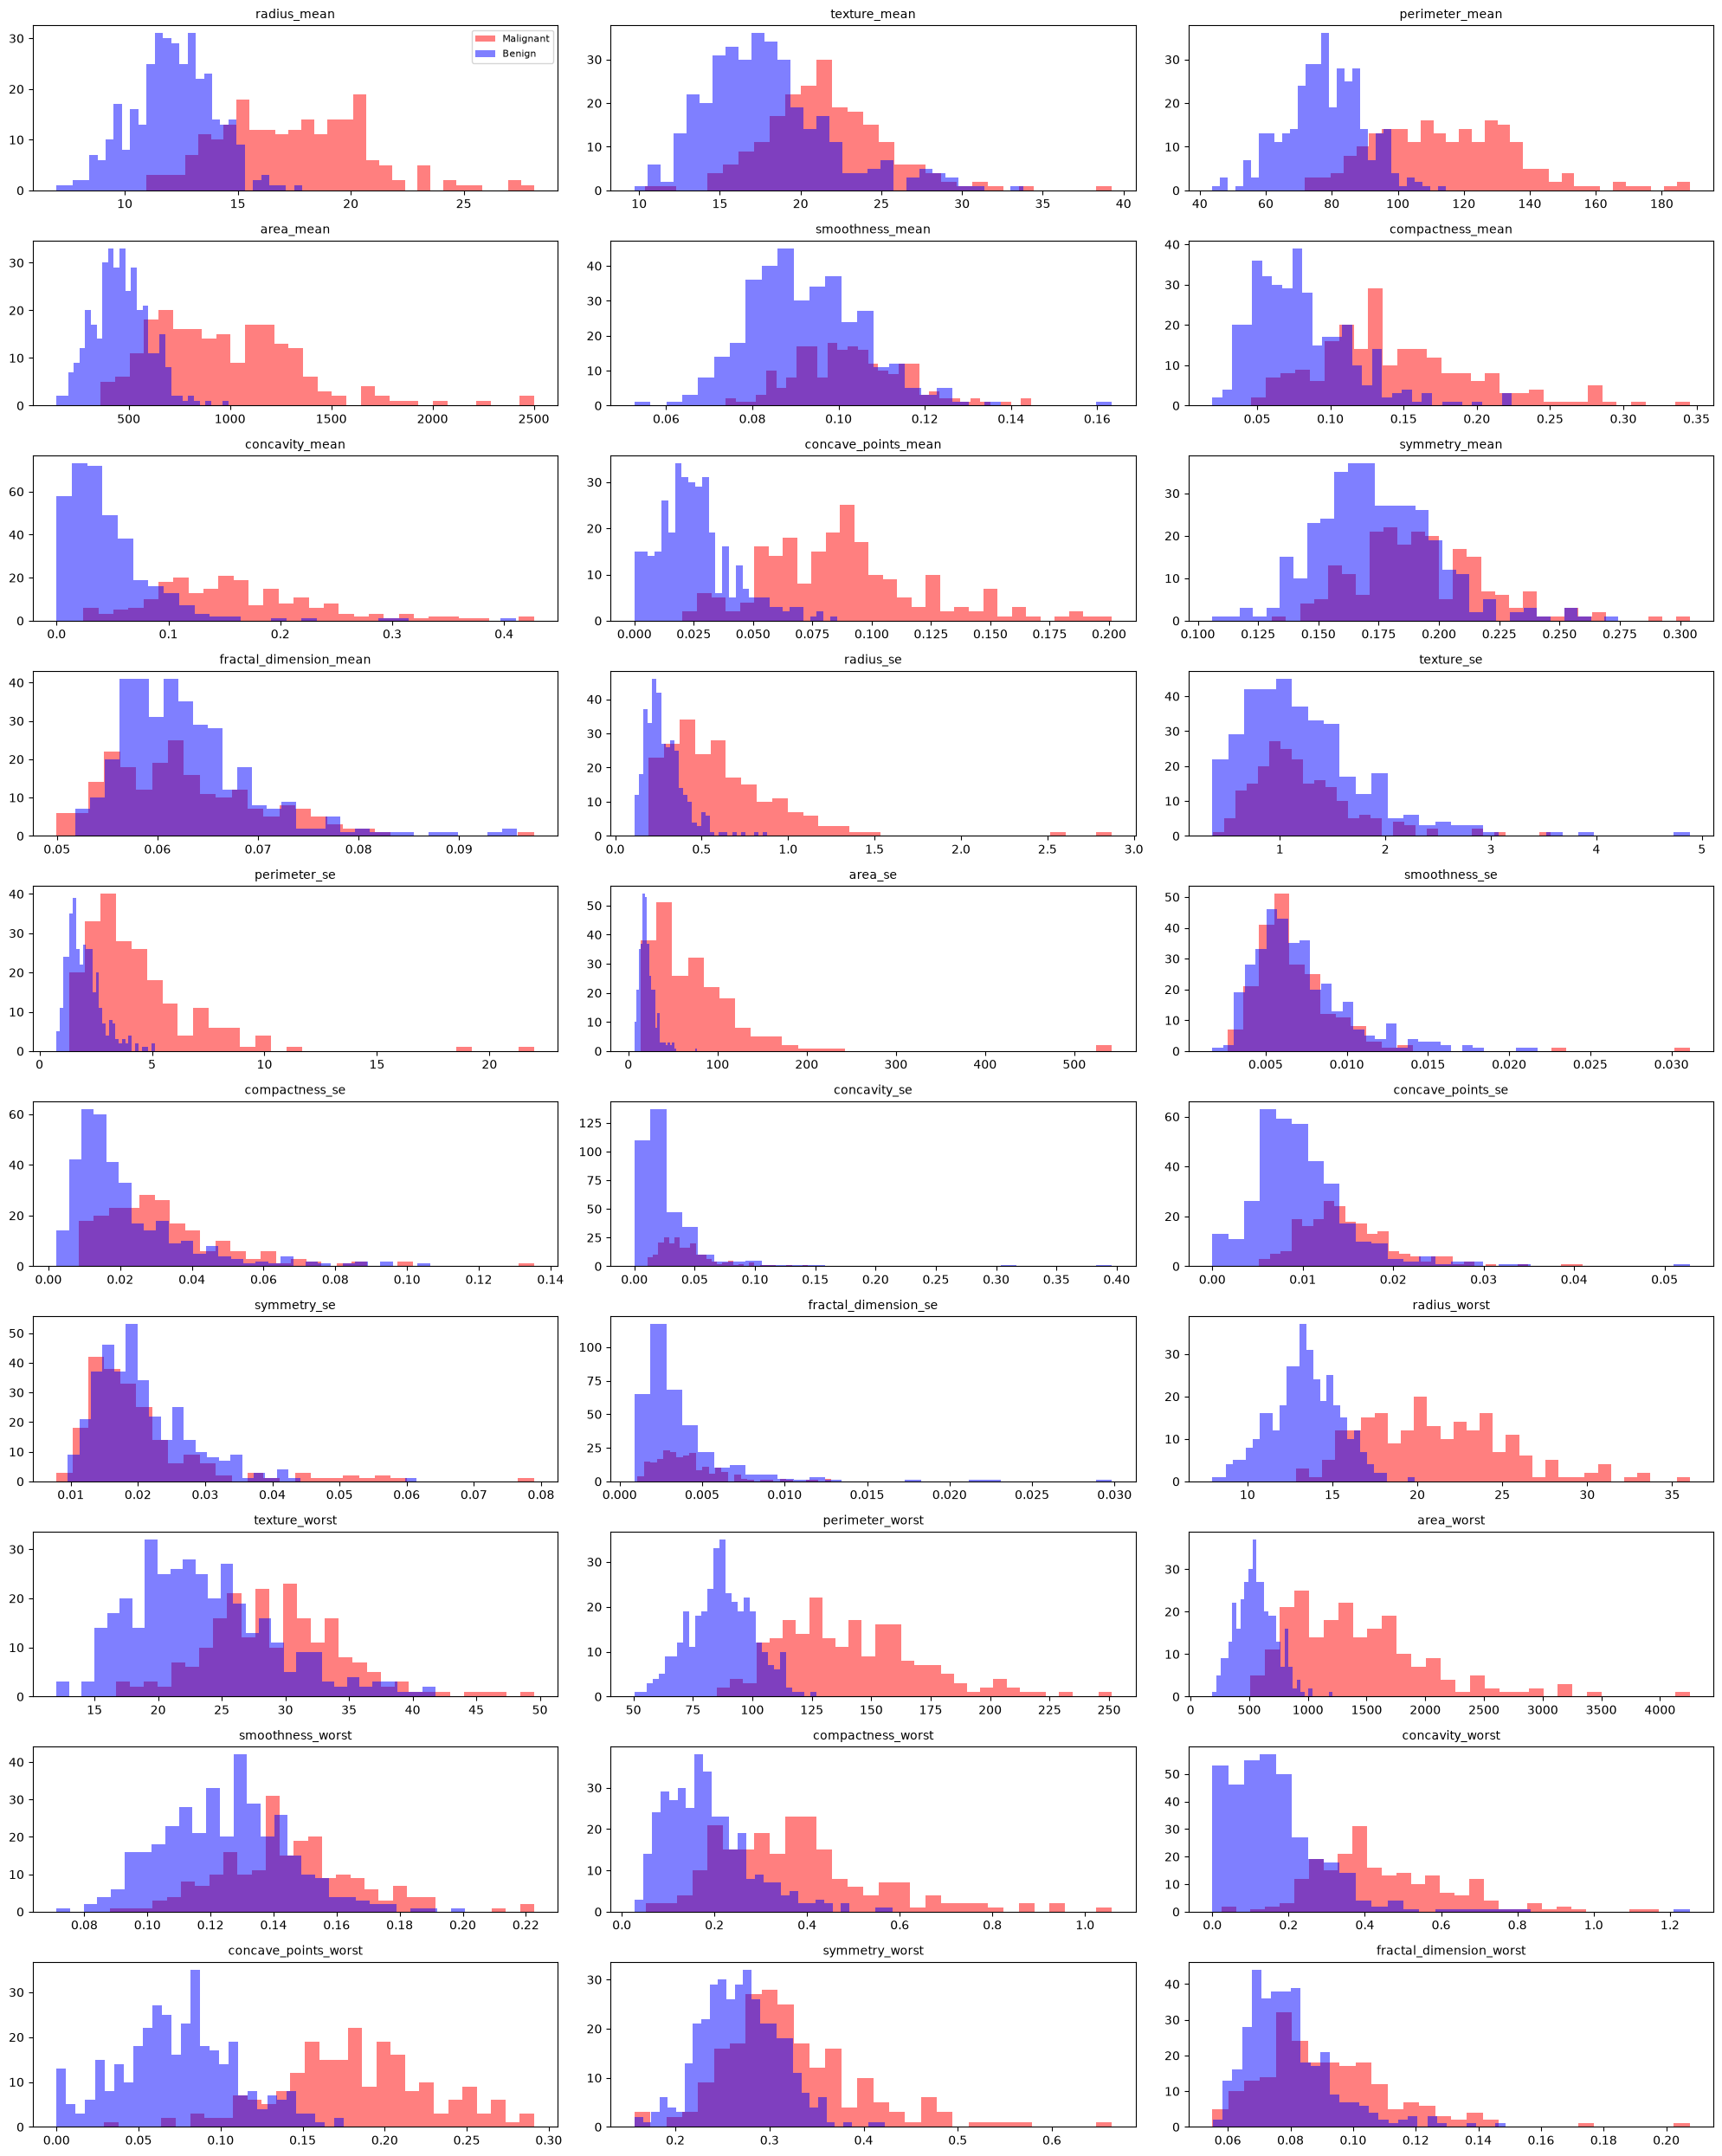

In [10]:
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(20, 25))

for i, (col, ax) in enumerate(zip(M_df.columns, axes.flatten())):
    ax.hist(M_df[col], bins=30, color="red", alpha=0.5, label="Malignant")
    ax.hist(B_df[col], bins=30, color="blue", alpha=0.5, label="Benign")
    ax.set_title(col, fontsize=10)
    if i == 0:
        ax.legend(fontsize=8)
        
plt.tight_layout()
plt.show()

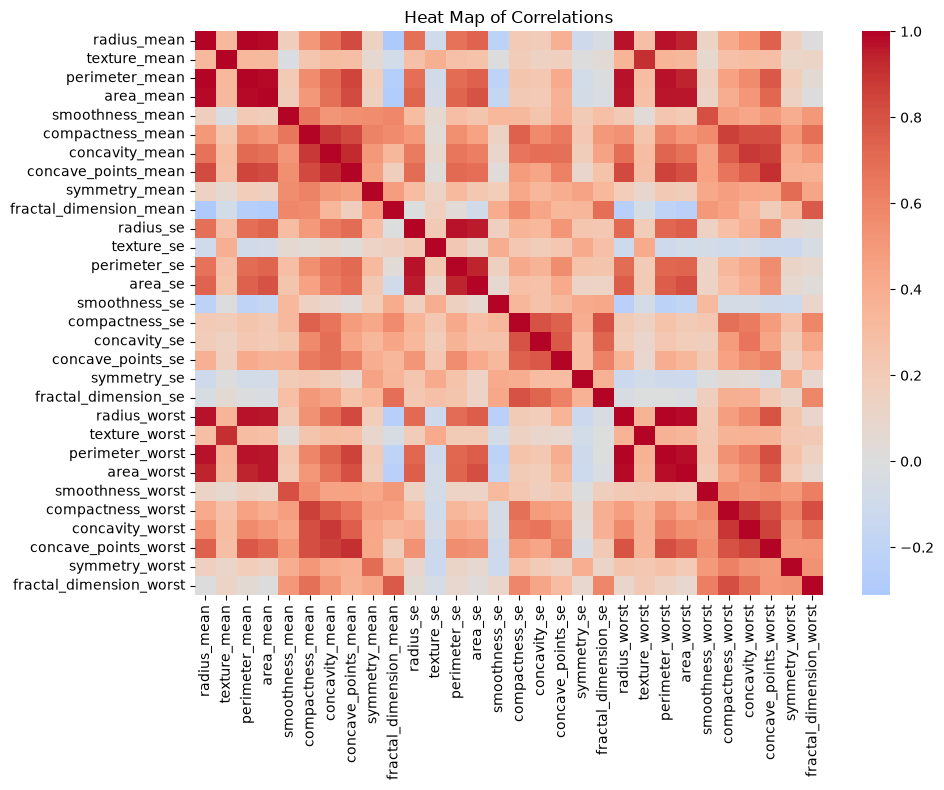

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(features_df.corr(), cmap='coolwarm', center=0, annot=False).set_title("Heat Map of Correlations")
plt.tight_layout()
plt.show()

In [12]:
print("Ranked Correlations: ")
corr = features_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = upper.stack().reset_index()
high_corr.columns = ['feature_1', 'feature_2', 'correlation']
high_corr[high_corr['correlation'] > 0.8].sort_values('correlation', ascending=False)

Ranked Correlations: 


,feature_1,feature_2,correlation
2,radius_mean,perimeter_mean,0.997855
622,radius_worst,perimeter_worst,0.993708
3,radius_mean,area_mean,0.987357
63,perimeter_mean,area_mean,0.986507
623,radius_worst,area_worst,0.984015
683,perimeter_worst,area_worst,0.977578
312,radius_se,perimeter_se,0.972794
82,perimeter_mean,perimeter_worst,0.970387
20,radius_mean,radius_worst,0.969539
80,perimeter_mean,radius_worst,0.969476
